Heart Disease Prediction — Notebook 3: Artificial Neural Network

This notebook covers Loading preprocessed data, Building a simple feedforward ANN for binary classification, Training with validation tracking & Evaluating with Accuracy, Precision, Recall, F1-score, ROC-AUC & Training history visualization (loss and accuracy curves), Confusion matrix and ROC curve, Direct comparison with traditional ML models from Notebook 2

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)

# Settings
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

# Reproducibility — set seeds for both numpy and TensorFlow
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.21.0
GPU available: False


In [2]:
# Load preprocessed data from Notebook 1
X_train = pd.read_csv('../outputs/processed_data/X_train.csv')
X_test = pd.read_csv('../outputs/processed_data/X_test.csv')
y_train = pd.read_csv('../outputs/processed_data/y_train.csv').squeeze()
y_test = pd.read_csv('../outputs/processed_data/y_test.csv').squeeze()

# Convert to numpy arrays for Keras
X_train_np = X_train.values
X_test_np = X_test.values
y_train_np = y_train.values
y_test_np = y_test.values

print(f"X_train: {X_train_np.shape}")
print(f"X_test:  {X_test_np.shape}")
print(f"Input features: {X_train_np.shape[1]}")

X_train: (237, 13)
X_test:  (60, 13)
Input features: 13


In [3]:
# Build the ANN
# Architecture: 13 -> 16 -> 8 -> 1
# Small network for a small dataset — too large would overfit instantly

model = Sequential([
    Input(shape=(X_train_np.shape[1],)),         # Input layer: 13 features
    Dense(16, activation='relu'),                 # Hidden layer 1
    Dropout(0.3),                                 # Regularization
    Dense(8, activation='relu'),                  # Hidden layer 2
    Dropout(0.2),                                 # Regularization
    Dense(1, activation='sigmoid')                # Output: binary classification
])

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display the architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369 (1.44 KB)

 Trainable params: 369 (1.44 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Early stopping: stop training if validation loss doesn't improve for 20 epochs
# This prevents overfitting and saves time
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Train the model
print("Training ANN...")
history = model.fit(
    X_train_np, y_train_np,
    validation_split=0.2,         # Use 20% of training data as validation set
    epochs=200,                    # Max epochs (early stopping will likely stop earlier)
    batch_size=16,                 # Small batch size for small dataset
    callbacks=[early_stopping],
    verbose=1
)

print(f"\nTraining stopped at epoch {len(history.history['loss'])}.")

Training ANN...
Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4550 - loss: 0.7481 - val_accuracy: 0.5625 - val_loss: 0.6492
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5079 - loss: 0.7260 - val_accuracy: 0.5417 - val_loss: 0.6288
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5238 - loss: 0.6908 - val_accuracy: 0.5833 - val_loss: 0.6125
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5503 - loss: 0.6963 - val_accuracy: 0.6667 - val_loss: 0.6032
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5238 - loss: 0.6918 - val_accuracy: 0.6875 - val_loss: 0.5944
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5608 - loss: 0.6735 - val_accuracy: 0.7500 - val_loss: 0.5869
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6190 - loss: 0.6622 - val_accuracy: 0.7500 - val_loss: 0.5795
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6508 - loss: 0.6337 - val_acc

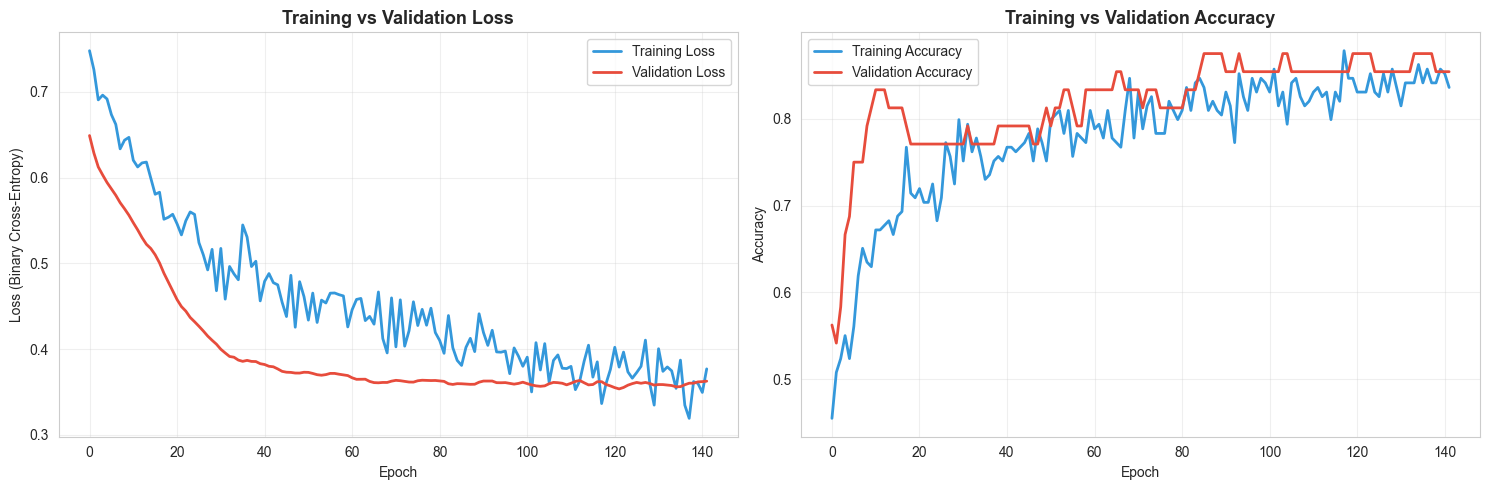

In [5]:
# Plot training vs validation loss and accuracy
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss curve
axes[0].plot(history.history['loss'], label='Training Loss', color='#3498db', lw=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='#e74c3c', lw=2)
axes[0].set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Binary Cross-Entropy)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(history.history['accuracy'], label='Training Accuracy', color='#3498db', lw=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='#e74c3c', lw=2)
axes[1].set_title('Training vs Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/18_ann_training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

In [6]:
# Get probability predictions
ann_pred_proba = model.predict(X_test_np, verbose=0).flatten()

# Convert probabilities to class labels (threshold = 0.5)
ann_pred = (ann_pred_proba >= 0.5).astype(int)

print(f"Sample predictions:")
print(f"Probabilities: {ann_pred_proba[:5]}")
print(f"Predicted:     {ann_pred[:5]}")
print(f"Actual:        {y_test_np[:5]}")

Sample predictions:
Probabilities: [0.00228055 0.25073656 0.05058903 0.31259283 0.05878224]
Predicted:     [0 0 0 0 0]
Actual:        [0 0 0 0 0]


In [7]:
# Compute all required metrics
ann_metrics = {
    'Model':     'ANN',
    'Accuracy':  accuracy_score(y_test_np, ann_pred),
    'Precision': precision_score(y_test_np, ann_pred),
    'Recall':    recall_score(y_test_np, ann_pred),
    'F1-Score':  f1_score(y_test_np, ann_pred),
    'ROC-AUC':   roc_auc_score(y_test_np, ann_pred_proba),
}

print("ANN Performance:")
print("=" * 40)
for metric, value in ann_metrics.items():
    if metric != 'Model':
        print(f"{metric:12s}: {value:.4f}")

print("\n" + "=" * 60)
print("Classification Report:")
print("=" * 60)
print(classification_report(y_test_np, ann_pred, target_names=['No Disease', 'Disease']))

ANN Performance:
Accuracy    : 0.8833
Precision   : 0.9565
Recall      : 0.7857
F1-Score    : 0.8627
ROC-AUC     : 0.9230

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.84      0.97      0.90        32
     Disease       0.96      0.79      0.86        28

    accuracy                           0.88        60
   macro avg       0.90      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60



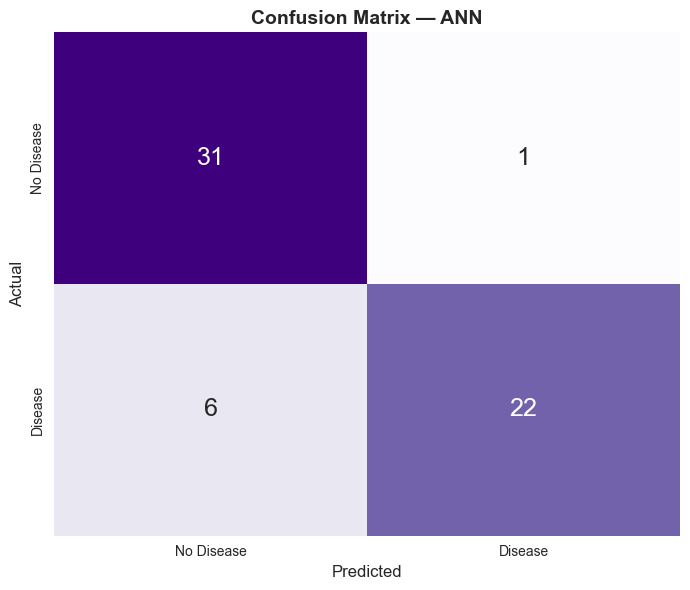

True Negatives:  31  (correctly identified as no disease)
False Positives: 1  (predicted disease but actually no disease)
False Negatives: 6  (predicted no disease but actually disease)  <-- critical errors in medical context
True Positives:  22  (correctly identified as disease)


In [8]:
# Confusion matrix for ANN
cm = confusion_matrix(y_test_np, ann_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'],
            cbar=False, annot_kws={'size': 18})
plt.title('Confusion Matrix — ANN', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/plots/20_ann_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# Detail breakdown
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}  (correctly identified as no disease)")
print(f"False Positives: {fp}  (predicted disease but actually no disease)")
print(f"False Negatives: {fn}  (predicted no disease but actually disease)  <-- critical errors in medical context")
print(f"True Positives:  {tp}  (correctly identified as disease)")

In [9]:
# Load traditional ML predictions saved from Notebook 2
ml_predictions = pd.read_csv('../outputs/processed_data/ml_predictions.csv')
ml_results = pd.read_csv('../outputs/processed_data/traditional_ml_results.csv', index_col=0)

print("Traditional ML results from Notebook 2:")
print(ml_results)
print("\nLoaded ML predictions shape:", ml_predictions.shape)

Traditional ML results from Notebook 2:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.9167     1.0000  0.8214     0.902   0.9520
Random Forest          0.8667     0.9545  0.7500     0.840   0.9386
SVM                    0.9167     1.0000  0.8214     0.902   0.9520

Loaded ML predictions shape: (60, 7)


In [10]:
# Combine ANN metrics with traditional ML results
all_results = ml_results.copy()
all_results.loc['ANN'] = {
    'Accuracy':  ann_metrics['Accuracy'],
    'Precision': ann_metrics['Precision'],
    'Recall':    ann_metrics['Recall'],
    'F1-Score':  ann_metrics['F1-Score'],
    'ROC-AUC':   ann_metrics['ROC-AUC'],
}

all_results = all_results.round(4)
print("All Models Performance Comparison:")
print("=" * 70)
all_results

All Models Performance Comparison:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.9167,1.0000,0.8214,0.9020,0.9520
Random Forest,0.8667,0.9545,0.7500,0.8400,0.9386
SVM,0.9167,1.0000,0.8214,0.9020,0.9520
ANN,0.8833,0.9565,0.7857,0.8627,0.9230


In [11]:
all_results.to_csv('../outputs/processed_data/all_models_results.csv')
print("Combined results saved.")

Combined results saved.


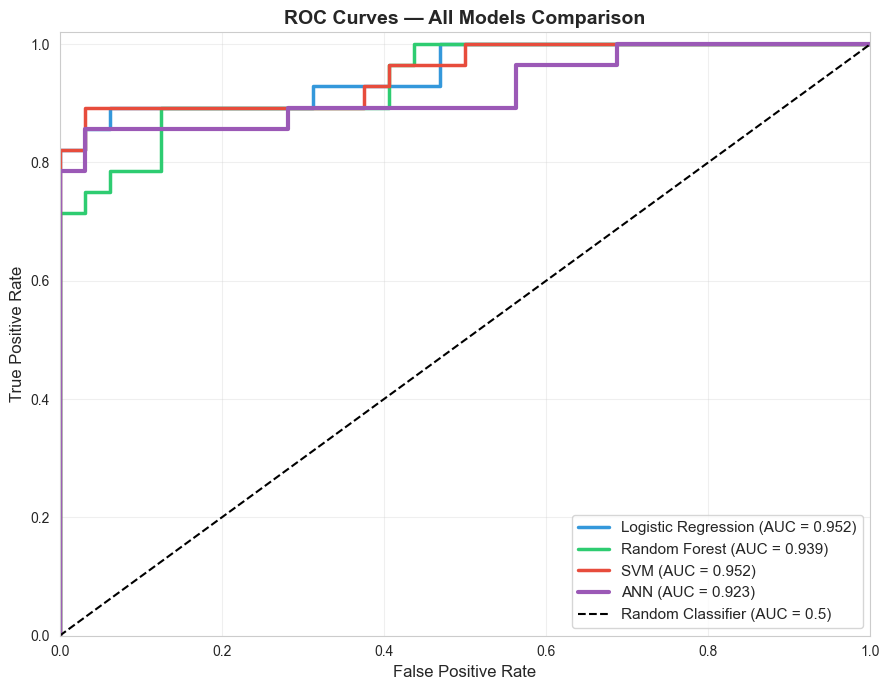

In [12]:
# ROC curves: all 4 models on a single plot
from sklearn.metrics import roc_curve

plt.figure(figsize=(9, 7))

# Traditional ML
fpr_lr, tpr_lr, _ = roc_curve(ml_predictions['y_test'], ml_predictions['lr_proba'])
auc_lr = roc_auc_score(ml_predictions['y_test'], ml_predictions['lr_proba'])
plt.plot(fpr_lr, tpr_lr, color='#3498db', lw=2.5, label=f'Logistic Regression (AUC = {auc_lr:.3f})')

fpr_rf, tpr_rf, _ = roc_curve(ml_predictions['y_test'], ml_predictions['rf_proba'])
auc_rf = roc_auc_score(ml_predictions['y_test'], ml_predictions['rf_proba'])
plt.plot(fpr_rf, tpr_rf, color='#2ecc71', lw=2.5, label=f'Random Forest (AUC = {auc_rf:.3f})')

fpr_svm, tpr_svm, _ = roc_curve(ml_predictions['y_test'], ml_predictions['svm_proba'])
auc_svm = roc_auc_score(ml_predictions['y_test'], ml_predictions['svm_proba'])
plt.plot(fpr_svm, tpr_svm, color='#e74c3c', lw=2.5, label=f'SVM (AUC = {auc_svm:.3f})')

# ANN
fpr_ann, tpr_ann, _ = roc_curve(y_test_np, ann_pred_proba)
auc_ann = roc_auc_score(y_test_np, ann_pred_proba)
plt.plot(fpr_ann, tpr_ann, color='#9b59b6', lw=3, linestyle='-', label=f'ANN (AUC = {auc_ann:.3f})')

# Random classifier reference
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/22_roc_curves_all_models.png', dpi=100, bbox_inches='tight')
plt.show()

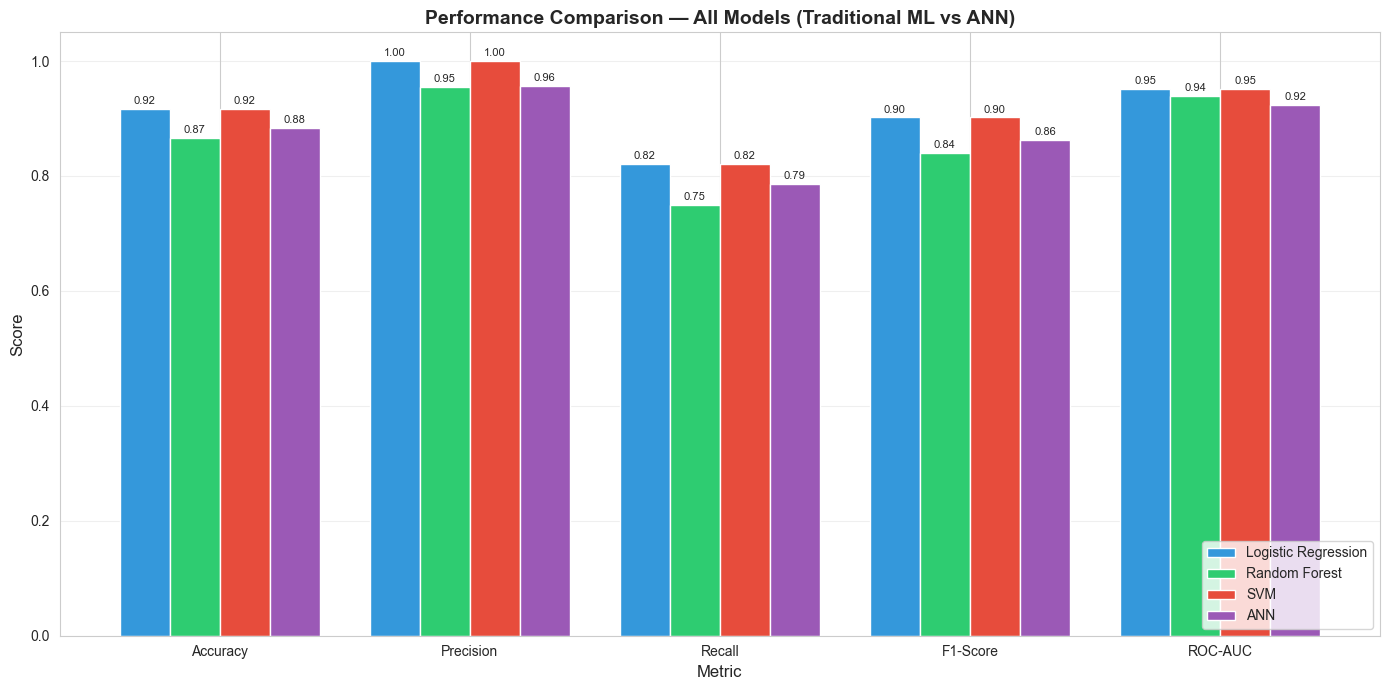

In [13]:
# Final comparison bar chart with all 4 models
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 7))

lr_scores  = [all_results.loc['Logistic Regression', m] for m in metrics_to_plot]
rf_scores  = [all_results.loc['Random Forest',       m] for m in metrics_to_plot]
svm_scores = [all_results.loc['SVM',                 m] for m in metrics_to_plot]
ann_scores = [all_results.loc['ANN',                 m] for m in metrics_to_plot]

bars1 = ax.bar(x - 1.5*width, lr_scores,  width, label='Logistic Regression', color='#3498db')
bars2 = ax.bar(x - 0.5*width, rf_scores,  width, label='Random Forest',       color='#2ecc71')
bars3 = ax.bar(x + 0.5*width, svm_scores, width, label='SVM',                 color='#e74c3c')
bars4 = ax.bar(x + 1.5*width, ann_scores, width, label='ANN',                 color='#9b59b6')

# Value labels
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Comparison — All Models (Traditional ML vs ANN)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/plots/23_all_models_comparison_bar.png', dpi=100, bbox_inches='tight')
plt.show()

In [14]:
# Save the trained ANN
import os
os.makedirs('../outputs/models', exist_ok=True)
model.save('../outputs/models/ann_model.keras')
print("ANN model saved to outputs/models/ann_model.keras")

ANN model saved to outputs/models/ann_model.keras


Notebook 3 Summary

ANN architecture
- Input layer: 13 features
- Hidden layer 1: 16 neurons, ReLU activation, Dropout(0.3)
- Hidden layer 2: 8 neurons, ReLU activation, Dropout(0.2)
- Output layer: 1 neuron, sigmoid activation (binary classification)
- Loss: binary cross-entropy
- Optimizer: Adam
- Early stopping on validation loss (patience=20, restore best weights)